In [1]:
import pandas as pd
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
def plot_is(df):
    _, ax = plt.subplots(figsize=(7.5, 5))
    ln1 = ax.plot(df['samples'], df['inception_score'], label='Inception Score', color="C0")[0]
    ax.set_title("Inception Score and FID")
    ax.set_xlabel("samples (millions)")

    # Format x-axis to show values in millions
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.0f}'))

    ax.set_ylabel(r"Inception Score $\rightarrow$", color="C0")
    ax.tick_params(axis='y', labelcolor="C0")
    ax.set_ybound(0.0)

    ax_twin = ax.twinx()
    ln2 = ax_twin.plot(df['samples'], df['fid_mean'], label='FID', color="C3")[0]
    ax_twin.set_ylabel(r"FID $\leftarrow$", color="C3")
    ax_twin.tick_params(axis='y', labelcolor="C3")

    ax.legend(handles=[ln1, ln2], loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2)

    plt.tight_layout()
    plt.show()

In [3]:
def plot_prec_rec(df):
    _, ax = plt.subplots(figsize=(7.5, 5))
    ln1 = ax.plot(df['samples'], df['precision'], label='Precision', color="C1")[0]
    ln2 = ax.plot(df['samples'], df['recall'], label='Recall', color="C2")[0]
    ax.set_title("Precision and Recall")
    ax.grid(True)

    # Format x-axis to show values in millions
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.0f}'))
    ax.set_xlabel("samples (millions)")
    
    ax.set_ylim(0.0, 1.0)
    ax.set_yticks(np.linspace(0, 1, 11))
    ax.set_yticklabels(['{:,.0%}'.format(x) for x in ax.get_yticks()])
    
    ax.legend(handles=[ln1, ln2], loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2)

    plt.tight_layout()
    plt.show()

In [4]:
def plot_losses(df):
    _, ax = plt.subplots(figsize=(7.5, 5))
    ln1 = ax.plot(df['samples'], df['discriminator_loss mean']      , linewidth=1, label='Adversarial loss', color="C0")[0]
    ln2 = ax.plot(df['samples'], df['loss1_grad_norm mean']         , linewidth=1, label='L1 loss', color="C1")[0]
    ln3 = ax.plot(df['samples'], df['recon_discriminator_loss mean'], linewidth=1, label='Reconstruction loss', color="C2")[0]
    ax.set_title("Training losses")
    ax.grid(True)

    # Format x-axis to show values in millions
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.0f}'))
    ax.set_xlabel("samples (millions)")
    
    # ax.set_ylim(0.0, 1.0)
    # ax.set_yticks(np.linspace(0, 1, 11))
    
    ax.legend(handles=[ln1, ln2, ln3], loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3)

    plt.tight_layout()
    plt.show()

In [5]:
def plot_stability(df):
    _, ax = plt.subplots(figsize=(7.5, 5))
    ln1 = ax.plot(df['samples'], df['grad_norm'], label='Gradient norm', color="C0")[0]
    ln2 = ax.plot(df['samples'], df['lg_loss_scale'], label='Log loss scale', color="C1")[0]
    ax.set_title("Training stability")
    ax.grid(True)

    # Format x-axis to show values in millions
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.0f}'))
    ax.set_xlabel("samples (millions)")
    
    # ax.set_ylim(0.0, 1.0)
    # ax.set_yticks(np.linspace(0, 1, 11))
    
    ax.legend(handles=[ln1, ln2], loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2)

    plt.tight_layout()
    plt.show()

### Stage 1

### Stage 2

In [6]:
try:
    stage2_df = pd.read_csv("stage2.csv")
    stage2_df = stage2_df.drop(columns=["fid_lower", "fid_upper", "sfid_lower", "sfid_upper"])
    print(f"Loaded stage2.csv — shape: {stage2_df.shape}")
    display(stage2_df.head())
except Exception as e:
    print(f"Error loading stage2.csv: {e}")

Loaded stage2.csv — shape: (43, 6)


,step,inception_score,fid_mean,sfid_mean,precision,recall
0,0,1.458297,188.56662,97.75565,0.00000,0.0
1,2000,1.460972,170.93524,99.92256,0.00004,0.0
2,4000,1.483020,154.17535,102.85075,0.00016,0.0
3,6000,1.514689,138.99174,103.45799,0.00076,0.0
4,8000,1.557302,125.62778,99.97919,0.00186,0.0


In [7]:
try:
    stage2_df2 = pd.read_csv("/home/bratosiewicz/data/last_stage2/11-03-pgd-ffhq-stage-2/progress.csv")
    stage2_df2 = stage2_df2.drop(columns=["discriminator_loss std", "recon_discriminator_loss std", "decoder_recon_loss std", "loss1_grad_norm std"])
    print(f"Loaded progress.csv — shape: {stage2_df2.shape}")
    display(stage2_df2.head())
except Exception as e:
    print(f"Error loading progress.csv: {e}")
    # create an empty DataFrame to avoid NameError later if df is used
    stage2_df2 = pd.DataFrame()

Loaded progress.csv — shape: (879, 9)


,decoder_recon_loss mean,discriminator_loss mean,grad_norm,lg_loss_scale,loss1_grad_norm mean,param_norm,recon_discriminator_loss mean,samples,step
0,0.588357,0.213286,19.336123,17.14162,0.484336,1345.558692,0.222120,12928,100
1,0.474321,0.123352,18.249348,17.07150,0.273066,1327.331251,0.120849,25728,200
2,0.362858,0.180235,31.633393,17.12150,0.260107,1327.346285,0.158184,38528,300
3,0.318501,0.180109,34.914132,17.17150,0.264791,1327.368786,0.252607,51328,400
4,0.299655,0.255419,34.905255,17.22150,0.281099,1327.396524,0.276205,64128,500


In [8]:
samples_for_df = np.interp(stage2_df['step'].values, stage2_df2['step'].values, stage2_df2['samples'].values)
samples_for_df[0] = 0.0
stage2_df['samples'] = samples_for_df
display(stage2_df.head())

,step,inception_score,fid_mean,sfid_mean,precision,recall,samples
0,0,1.458297,188.56662,97.75565,0.00000,0.0,0.0
1,2000,1.460972,170.93524,99.92256,0.00004,0.0,256128.0
2,4000,1.483020,154.17535,102.85075,0.00016,0.0,512128.0
3,6000,1.514689,138.99174,103.45799,0.00076,0.0,768128.0
4,8000,1.557302,125.62778,99.97919,0.00186,0.0,1024128.0


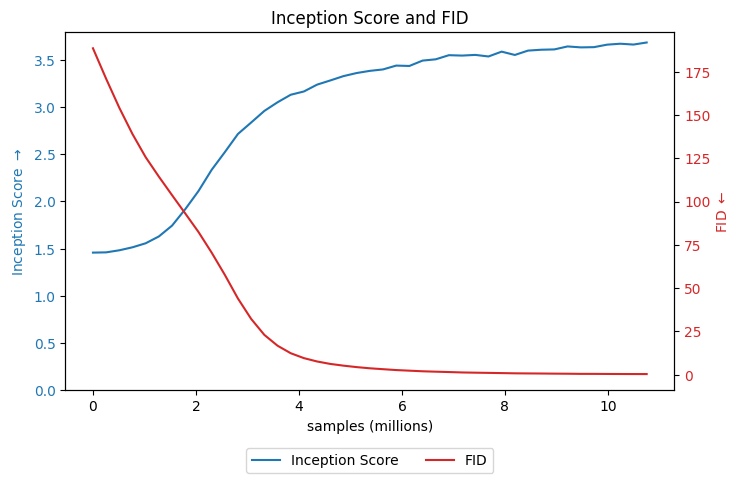

In [9]:
plot_is(stage2_df)

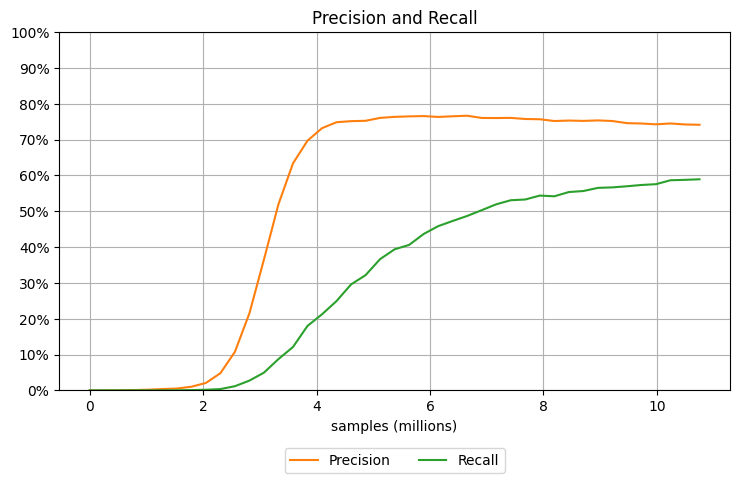

In [10]:
plot_prec_rec(stage2_df)

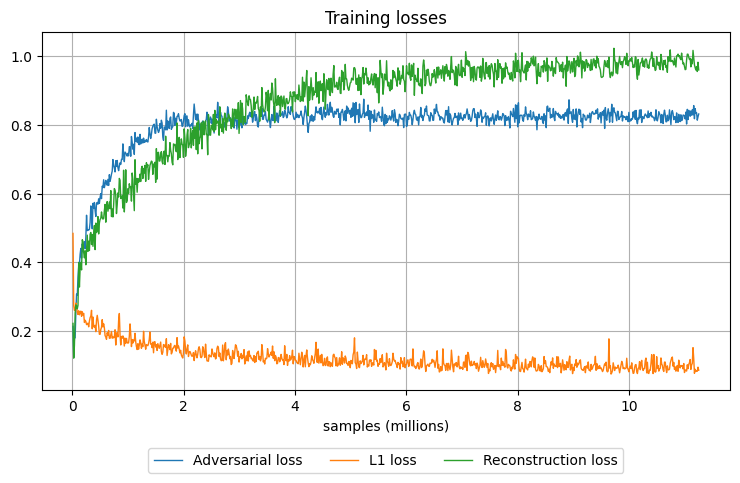

In [11]:
plot_losses(stage2_df2)

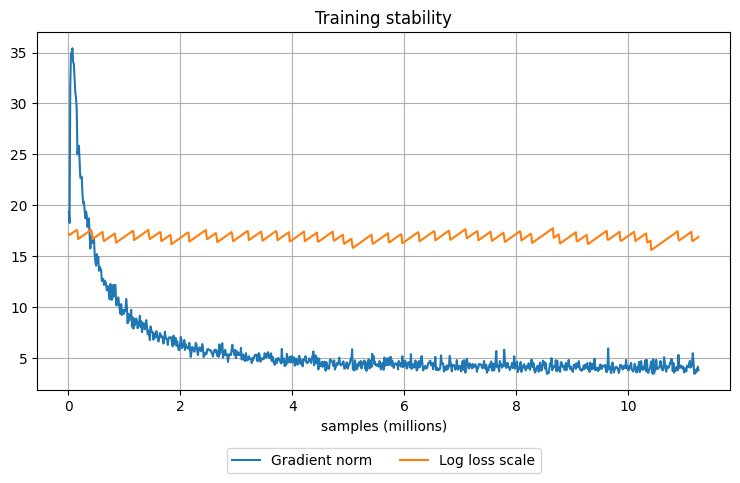

In [12]:
plot_stability(stage2_df2)